# Exploratory Data Analysis 
# FD001 and FD003

This notebook explores the FD001 and FD003 subsets of the C-MAPSS turbofan engine data. Both subsets use one operating condition, which makes them suitable for the first stage of the project.
The notebook is organized around reusable functions so that the same checks and plots can be applied to both datasets.

Data loading
- `load_training_data(dataset_id)`
- `load_test_data(dataset_id)`
- `load_rul(dataset_id)`

Preprocessing and column selection
- `attach_test_rul(test_df, rul_series)`
- `sensor_cols(df)`
- `setting_cols(df)`
- `unit_lifetimes(df)`
- `constant_sensors(df, threshold=1e-5)`
- `drop_constant_sensors(df, threshold=1e-5)`
- `clip_rul(df, cap=125)`

Data checks and sensor metadata
- `data_summary(data)`
- `sensors_variance_classification(data)`
- `sensor_number(sensor)`
- `sensor_label(sensor, short=False)`
- `sensor_reference_table(df)`

Visual exploration
- `rul_distribution(df, bins=30)`
- `sensor_grid(df, sensors=None, units=None, n_units=5, n_cols=4)`
- `correlation_heatmap(df, columns=None)`
- `sensor_boxplot_grid(df, sensors=None, n_cols=4)`
- `sensor_variance_bar(df)`
- `sensor_degradation_trend(df, sensors=None, n_cols=4, max_rul=125)`

The original RUL values are kept for reference. A separate clipped dataframe is created for experiments that use the conventional RUL cap of 125 cycles.

## Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading

In [2]:
# Define the base columns and sensor metadata used throughout the notebook.
# The dataset README defines 5 base columns and 21 sensor measurements.

BASE_COLUMNS = [
    'unit_number',
    'time_cycles',
    'op_setting_1',
    'op_setting_2',
    'op_setting_3',
]

# Sensor descriptions are based on the C-MAPSS reference paper.

SENSOR_INFO = {
    1: ('T2', 'Total temperature at fan inlet', '°R'),
    2: ('T24', 'Total temperature at LPC outlet', '°R'),
    3: ('T30', 'Total temperature at HPC outlet', '°R'),
    4: ('T50', 'Total temperature at LPT outlet', '°R'),
    5: ('P2', 'Pressure at fan inlet', 'psia'),
    6: ('P15', 'Total pressure in bypass-duct', 'psia'),
    7: ('P30', 'Total pressure at HPC outlet', 'psia'),
    8: ('Nf', 'Physical fan speed', 'rpm'),
    9: ('Nc', 'Physical core speed', 'rpm'),
    10: ('epr', 'Engine pressure ratio (P50/P2)', '--'),
    11: ('Ps30', 'Static pressure at HPC outlet', 'psia'),
    12: ('phi', 'Ratio of fuel flow to Ps30', 'pps/psi'),
    13: ('NRf', 'Corrected fan speed', 'rpm'),
    14: ('NRc', 'Corrected core speed', 'rpm'),
    15: ('BPR', 'Bypass Ratio', '--'),
    16: ('farB', 'Burner fuel-air ratio', '--'),
    17: ('htBleed', 'Bleed Enthalpy', '--'),
    18: ('Nf_dmd', 'Demanded fan speed', 'rpm'),
    19: ('PCNfR_dmd', 'Demanded corrected fan speed', 'rpm'),
    20: ('W31', 'HPT coolant bleed', 'lbm/s'),
    21: ('W32', 'LPT coolant bleed', 'lbm/s'),
}

In [3]:
def load_training_data(dataset_id):
    path = f'../data/train_{dataset_id}.txt'
    dataframe = pd.read_csv(path, sep=r'\s+', header=None)
    sensor_count = len(dataframe.columns) - len(BASE_COLUMNS)
    sensor_columns = [
        f'sensor_measure_{i}' for i in range(1, sensor_count + 1)
    ]
    dataframe.columns = BASE_COLUMNS + sensor_columns
    return dataframe

In [4]:
def load_test_data(dataset_id):
    path = f'../data/test_{dataset_id}.txt'
    dataframe = pd.read_csv(path, sep=r'\s+', header=None)
    sensor_count = len(dataframe.columns) - len(BASE_COLUMNS)
    sensor_columns = [
        f'sensor_measure_{i}' for i in range(1, sensor_count + 1)
    ]
    dataframe.columns = BASE_COLUMNS + sensor_columns
    return dataframe


In [5]:
def load_rul(dataset_id):
    path = f'../data/RUL_{dataset_id}.txt'
    rul = pd.read_csv(path, sep=r'\s+', header=None, names=['RUL'])
    rul.index = rul.index + 1 
    rul.index.name = 'unit_number'
    return rul['RUL']


## Preprocessing and Column Selection

In [6]:
# True RUL
def attach_test_rul(test_df, rul_series):
    test_df = test_df.copy()
    max_cycle = test_df.groupby('unit_number')['time_cycles'].transform('max')
    final_rul = test_df['unit_number'].map(rul_series)
    test_df['RUL'] = final_rul + (max_cycle - test_df['time_cycles'])
    return test_df

In [7]:
def sensor_cols(df):
    return [column for column in df.columns if column.startswith('sensor')]

def setting_cols(df):
    return [column for column in df.columns if column.startswith('op_setting')]

In [8]:
def unit_lifetimes(df):
    return df.groupby(BASE_COLUMNS[0])[BASE_COLUMNS[1]].max()

## Data Checks and Sensor Metadata

In [9]:
def data_summary(data):
    summary = pd.DataFrame({
        'Metric': ['Rows', 'Units', 'Max Cycle', 'Missing values', 'Duplicate rows'],
        'Value': [
            len(data),
            data['unit_number'].nunique(),
            data['time_cycles'].max(),
            int(data.isna().sum().sum()),
            int(data.duplicated().sum()),
        ],
    })

    return summary

In [10]:
def sensors_variance_classification(data):
    variance = data[sensor_cols(data)].var()
    variance_classification = pd.DataFrame({
        'Sensor': variance.index,
        'Variance': variance.values,
        'Classification': ['Low' if v < 0.1 else 'Medium' if v < 1 else 'High' for v in variance.values],
    })
    return variance_classification

Since we have a lot of sensors, it would be helpful to have a reference table that shows the sensor number, symbol, description, and unit. This will make it easier to understand the data and identify any issues especially during visualization.

In [11]:
def sensor_number(sensor):
    match = re.search(r'(\d+)$', sensor)
    return int(match.group(1)) if match else None

def sensor_label(sensor, short=False):
    number = sensor_number(sensor)
    if number is None:
        return sensor
    
    info = SENSOR_INFO.get(number)
    if info is None:
        return sensor

    symbol, description, unit = info
    if short:
        return f'{symbol} ({unit})' if unit != '--' else symbol
    return f'{symbol} – {description} ({unit})' if unit != '--' else f'{symbol} – {description}'

def sensor_reference_table(df):
    rows = []
    for sensor in sensor_cols(df):
        number = sensor_number(sensor)
        if number is None:
            continue
        info = SENSOR_INFO.get(number)
        if info is None:
            continue
        symbol, description, unit = info
        rows.append({'column': sensor, 'symbol': symbol, 'description': description, 'unit': unit})
    return pd.DataFrame(rows)

## Visual Exploration

In [12]:
sns.set_theme(style='whitegrid', font='sans-serif')

plt.rcParams.update({
    'font.sans-serif': ['Segoe UI', 'DejaVu Sans', 'Helvetica', 'Arial'],
    'axes.edgecolor': '#CBD5E1',
    'axes.linewidth': 0.8,
    'text.color': '#0F172A',
    'axes.labelcolor': '#475569',
    'xtick.color': '#64748B',
    'ytick.color': '#64748B',
    'grid.color': '#F1F5F9',
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
    'figure.dpi': 100,
    'figure.autolayout': True
})

In [13]:
def rul_distribution(df, bins=30):
    lifetimes = unit_lifetimes(df)
    plt.figure(figsize=(8, 5))
    sns.histplot(lifetimes, bins=bins, kde=True, color='#2563EB')
    plt.title('Distribution of Engine Lifetimes (Max Cycles)')
    plt.xlabel('Cycles')
    plt.ylabel('Number of Units')
    plt.show()

In [14]:
def sensor_grid(df, sensors=None, units=None, n_units=5, n_cols=4):
        sensors = sensors if sensors is not None else sensor_cols(df)
        if units is None:
            units = df[BASE_COLUMNS[0]].unique()[:n_units]

        n_rows = int(np.ceil(len(sensors) / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
        axes = axes.flatten()

        for i, sensor in enumerate(sensors):
            ax = axes[i]
            for unit in units:
                unit_df = df[df[BASE_COLUMNS[0]] == unit]
                ax.plot(unit_df[BASE_COLUMNS[1]], unit_df[sensor], linewidth=1)
            ax.set_title(sensor_label(sensor, short=True), fontsize=10)
            ax.set_xlabel('Cycle')

        for j in range(len(sensors), len(axes)):
            fig.delaxes(axes[j])

        plt.suptitle('Sensor Trends by Unit', y=1.02)
        plt.tight_layout()
        plt.show()


In [15]:
def correlation_heatmap(df, columns=None):
    columns = columns if columns is not None else sensor_cols(df)
    corr = df[columns].corr()
    labels = [sensor_label(c, short=True) for c in columns]
    corr.index = labels
    corr.columns = labels
    plt.figure(figsize=(min(1 + 0.5 * len(columns), 16), min(1 + 0.5 * len(columns), 14)))
    sns.heatmap(corr, cmap='coolwarm', annot=len(columns) <= 15, fmt='.2f', center=0)
    plt.title('Sensor Correlation Heatmap')
    plt.show()

In [16]:
def sensor_boxplot_grid(df, sensors=None, n_cols=4):
    sensors = sensors if sensors is not None else sensor_cols(df)
    n_rows = int(np.ceil(len(sensors) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3 * n_rows))
    axes = axes.flatten()

    for i, sensor in enumerate(sensors):
        sns.boxplot(data=df, y=sensor, color='#2563EB', ax=axes[i])
        axes[i].set_title(sensor_label(sensor, short=True), fontsize=10)
        axes[i].set_ylabel('')

    for j in range(len(sensors), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Sensor Distributions', y=1.02)
    plt.tight_layout()
    plt.show()

In [17]:
def sensor_variance_bar(df):
    variances = df[sensor_cols(df)].std().sort_values(ascending=False)
    labels = [sensor_label(s, short=True) for s in variances.index]
    plt.figure(figsize=(9, 6))
    sns.barplot(x=variances.values, y=labels, color='#2563EB')
    plt.title('Sensor Standard Deviation')
    plt.xlabel('Std Dev')
    plt.ylabel('Sensor')
    plt.show()

## EDA Summary Functions

In [18]:
def eda(df):

    print("Data Summary:")
    display(data_summary(df))
    
    print("\nSensor Reference:")
    display(sensor_reference_table(df))
    
    print("\nSensor Variance Classification:")
    display(sensors_variance_classification(df))
    
    print("\nRUL Distribution:")
    rul_distribution(df)
    
    print("\nSensor Grid:")
    sensor_grid(df)
    
    print("\nCorrelation Heatmap:")
    correlation_heatmap(df)
    
    print("\nSensor Boxplot Grid:")
    sensor_boxplot_grid(df)
    
    print("\nSensor Variance Bar:")
    sensor_variance_bar(df)

In [19]:
def sensor_degradation_trend(df, sensors=None, n_cols=4, max_rul=125):
    sensors = sensors if sensors is not None else sensor_cols(df)
    plot_df = df[df['RUL'] <= max_rul]
    grouped = plot_df.groupby('RUL')[sensors].mean().sort_index(ascending=False)

    n_rows = int(np.ceil(len(sensors) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = axes.flatten()

    for i, sensor in enumerate(sensors):
        ax = axes[i]
        ax.plot(grouped.index, grouped[sensor], linewidth=1.2, color='#2563EB')
        ax.invert_xaxis()
        ax.set_title(sensor_label(sensor, short=True), fontsize=10)
        ax.set_xlabel('RUL (cycles to failure)')

    for j in range(len(sensors), len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle('Mean Sensor Value vs. Remaining Useful Life', y=1.02)
    plt.tight_layout()
    plt.show()


## Modeling Preparation

In [20]:
def constant_sensors(df, threshold=1e-5):
    variances = df[sensor_cols(df)].var()
    return variances[variances < threshold].index.tolist()

def drop_constant_sensors(df, threshold=1e-5):
    to_drop = constant_sensors(df, threshold)
    return df.drop(columns=to_drop), to_drop


The standard C-MAPSS practice is to cap RUL at a constant (commonly 125) because early in an engine life the degradation signal is flat and unlearnable

In [21]:
def clip_rul(df, cap=125):
    df = df.copy()
    df['RUL'] = df['RUL'].clip(upper=cap)
    return df

# FD001 EDA

## Train Data

In [22]:
fd001_df = load_training_data('FD001')
fd001_df.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measure_1,sensor_measure_2,sensor_measure_3,sensor_measure_4,sensor_measure_5,...,sensor_measure_12,sensor_measure_13,sensor_measure_14,sensor_measure_15,sensor_measure_16,sensor_measure_17,sensor_measure_18,sensor_measure_19,sensor_measure_20,sensor_measure_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Data Summary:


,Metric,Value
0,Rows,20631
1,Units,100
2,Max Cycle,362
3,Missing values,0
4,Duplicate rows,0



Sensor Reference:


,column,symbol,description,unit
0,sensor_measure_1,T2,Total temperature at fan inlet,°R
1,sensor_measure_2,T24,Total temperature at LPC outlet,°R
2,sensor_measure_3,T30,Total temperature at HPC outlet,°R
3,sensor_measure_4,T50,Total temperature at LPT outlet,°R
4,sensor_measure_5,P2,Pressure at fan inlet,psia
5,sensor_measure_6,P15,Total pressure in bypass-duct,psia
6,sensor_measure_7,P30,Total pressure at HPC outlet,psia
7,sensor_measure_8,Nf,Physical fan speed,rpm
8,sensor_measure_9,Nc,Physical core speed,rpm
9,sensor_measure_10,epr,Engine pressure ratio (P50/P2),--



Sensor Variance Classification:


,Sensor,Variance,Classification
0,sensor_measure_1,0.000000e+00,Low
1,sensor_measure_2,2.500533e-01,Medium
2,sensor_measure_3,3.759099e+01,High
3,sensor_measure_4,8.101089e+01,High
4,sensor_measure_5,2.840037e-29,Low
5,sensor_measure_6,1.929279e-06,Low
6,sensor_measure_7,7.833883e-01,Medium
7,sensor_measure_8,5.038938e-03,Low
8,sensor_measure_9,4.876536e+02,High
9,sensor_measure_10,0.000000e+00,Low



RUL Distribution:


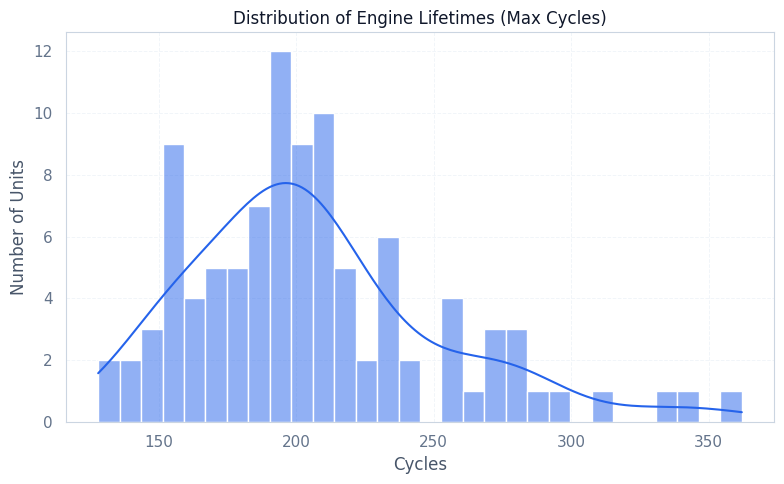


Sensor Grid:


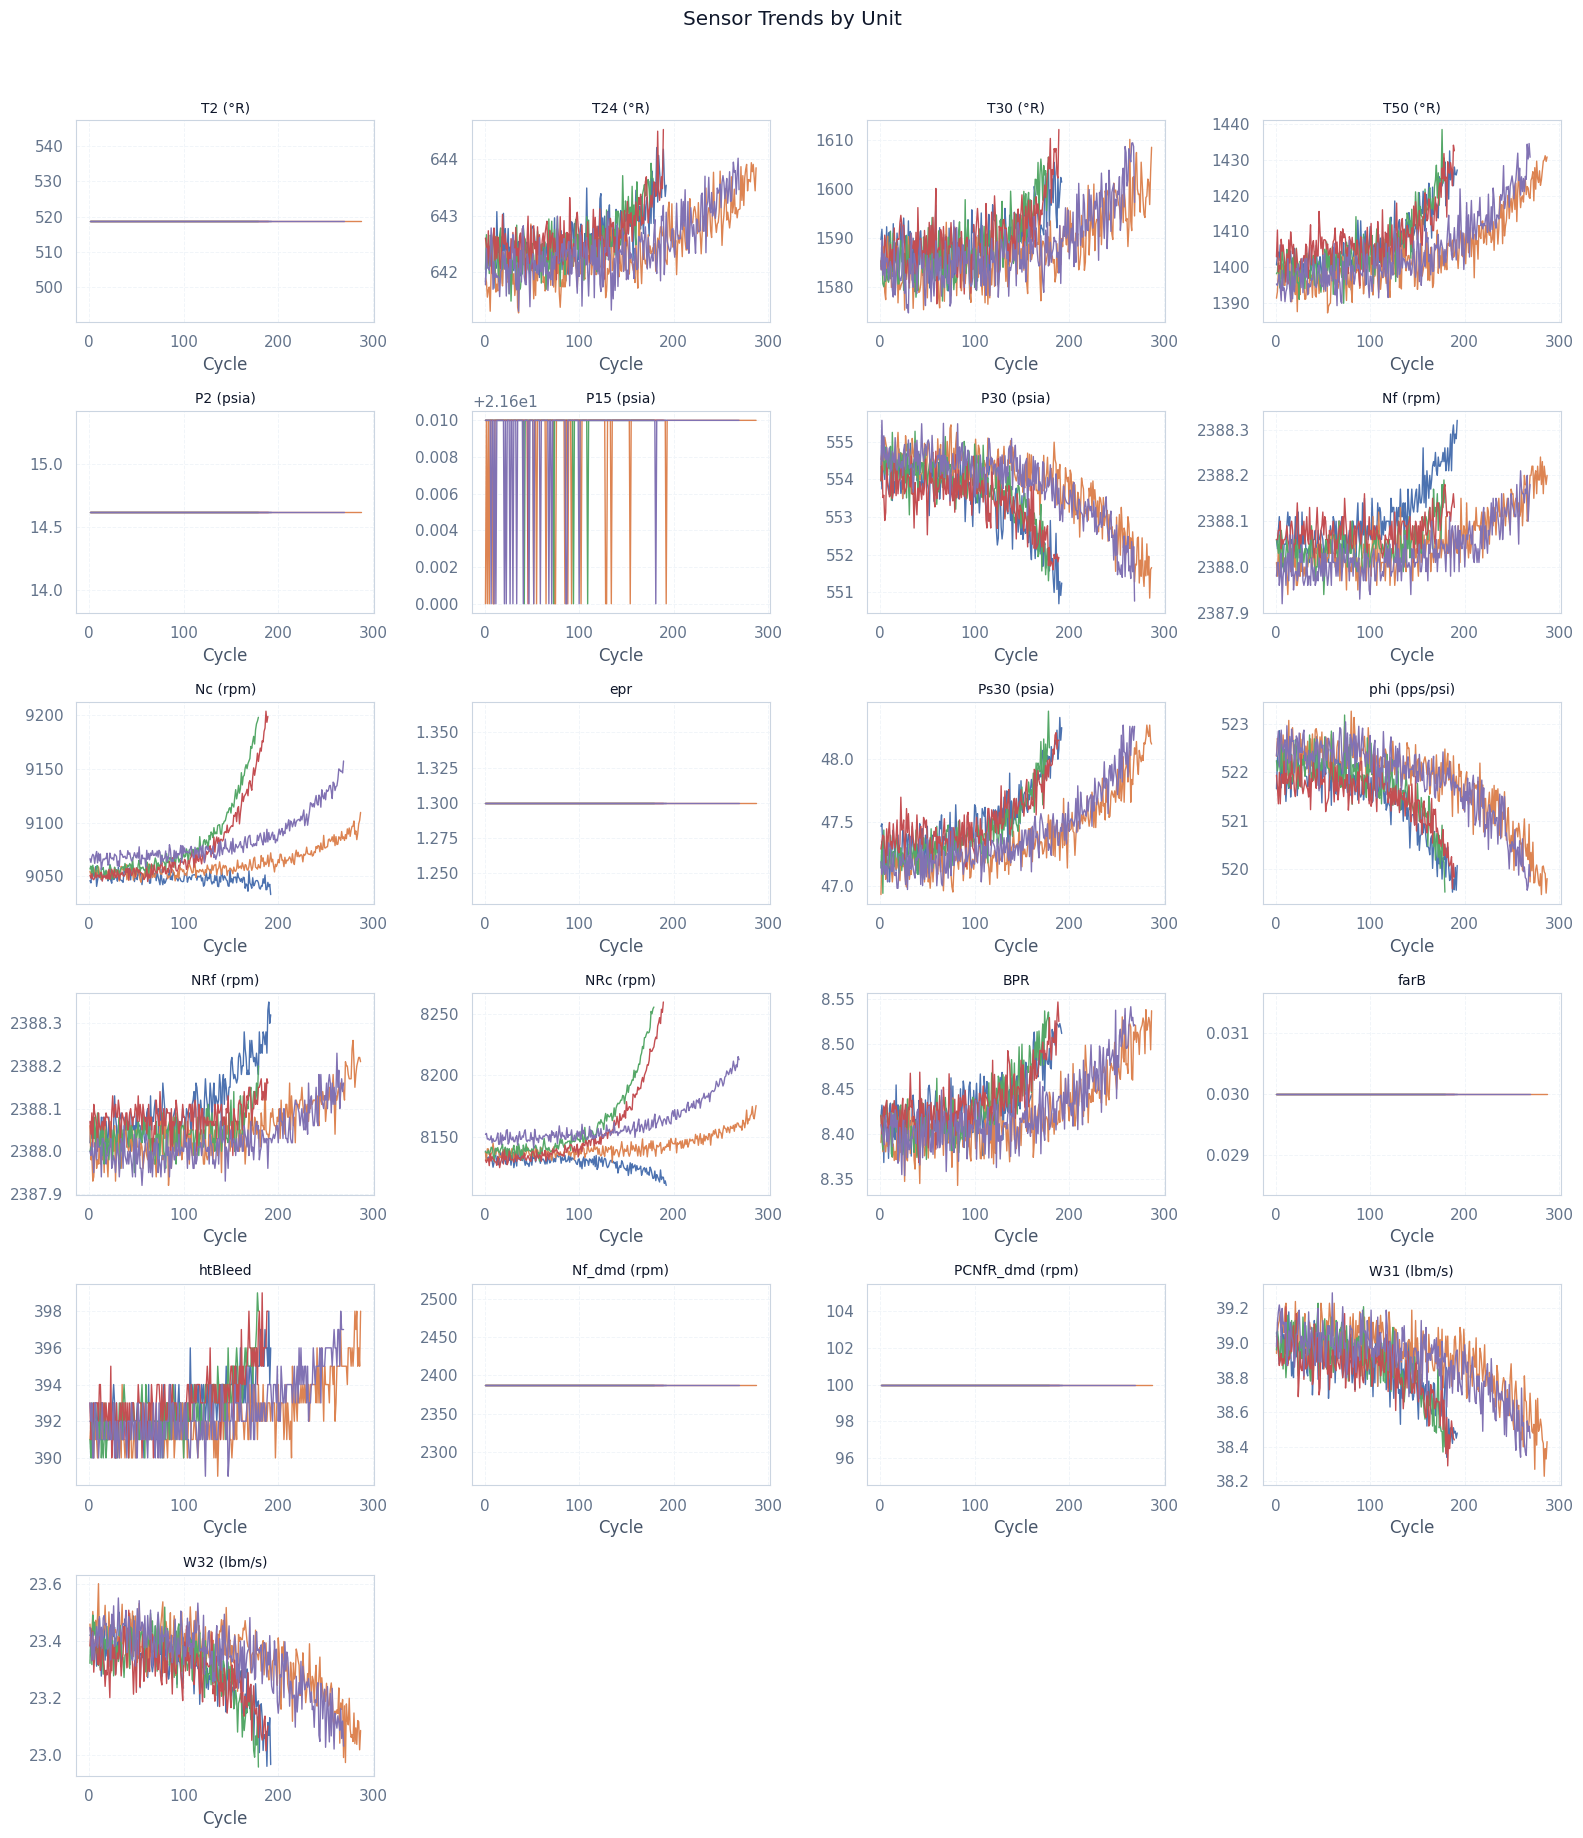


Correlation Heatmap:


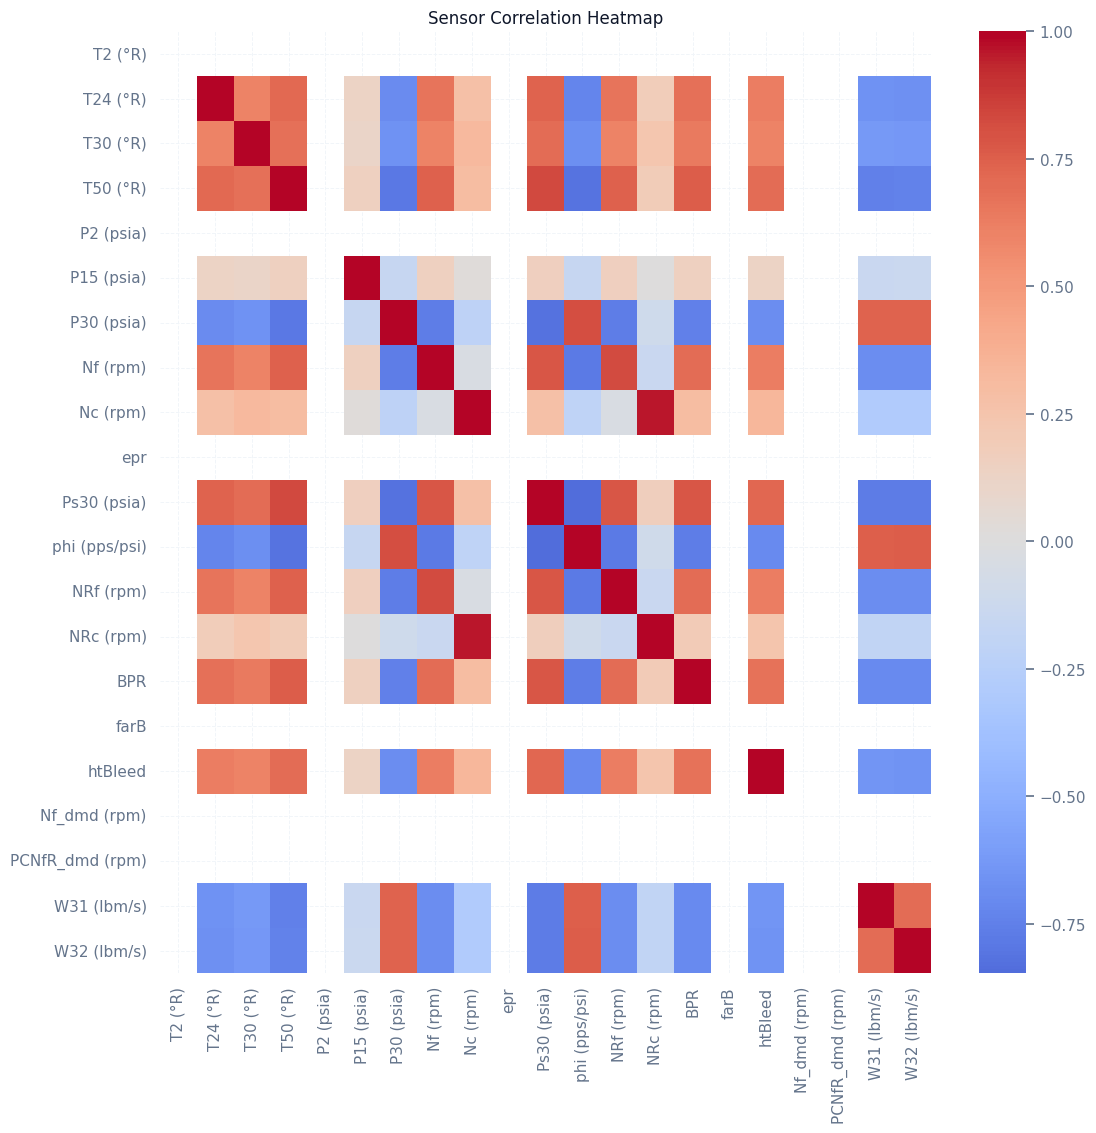


Sensor Boxplot Grid:


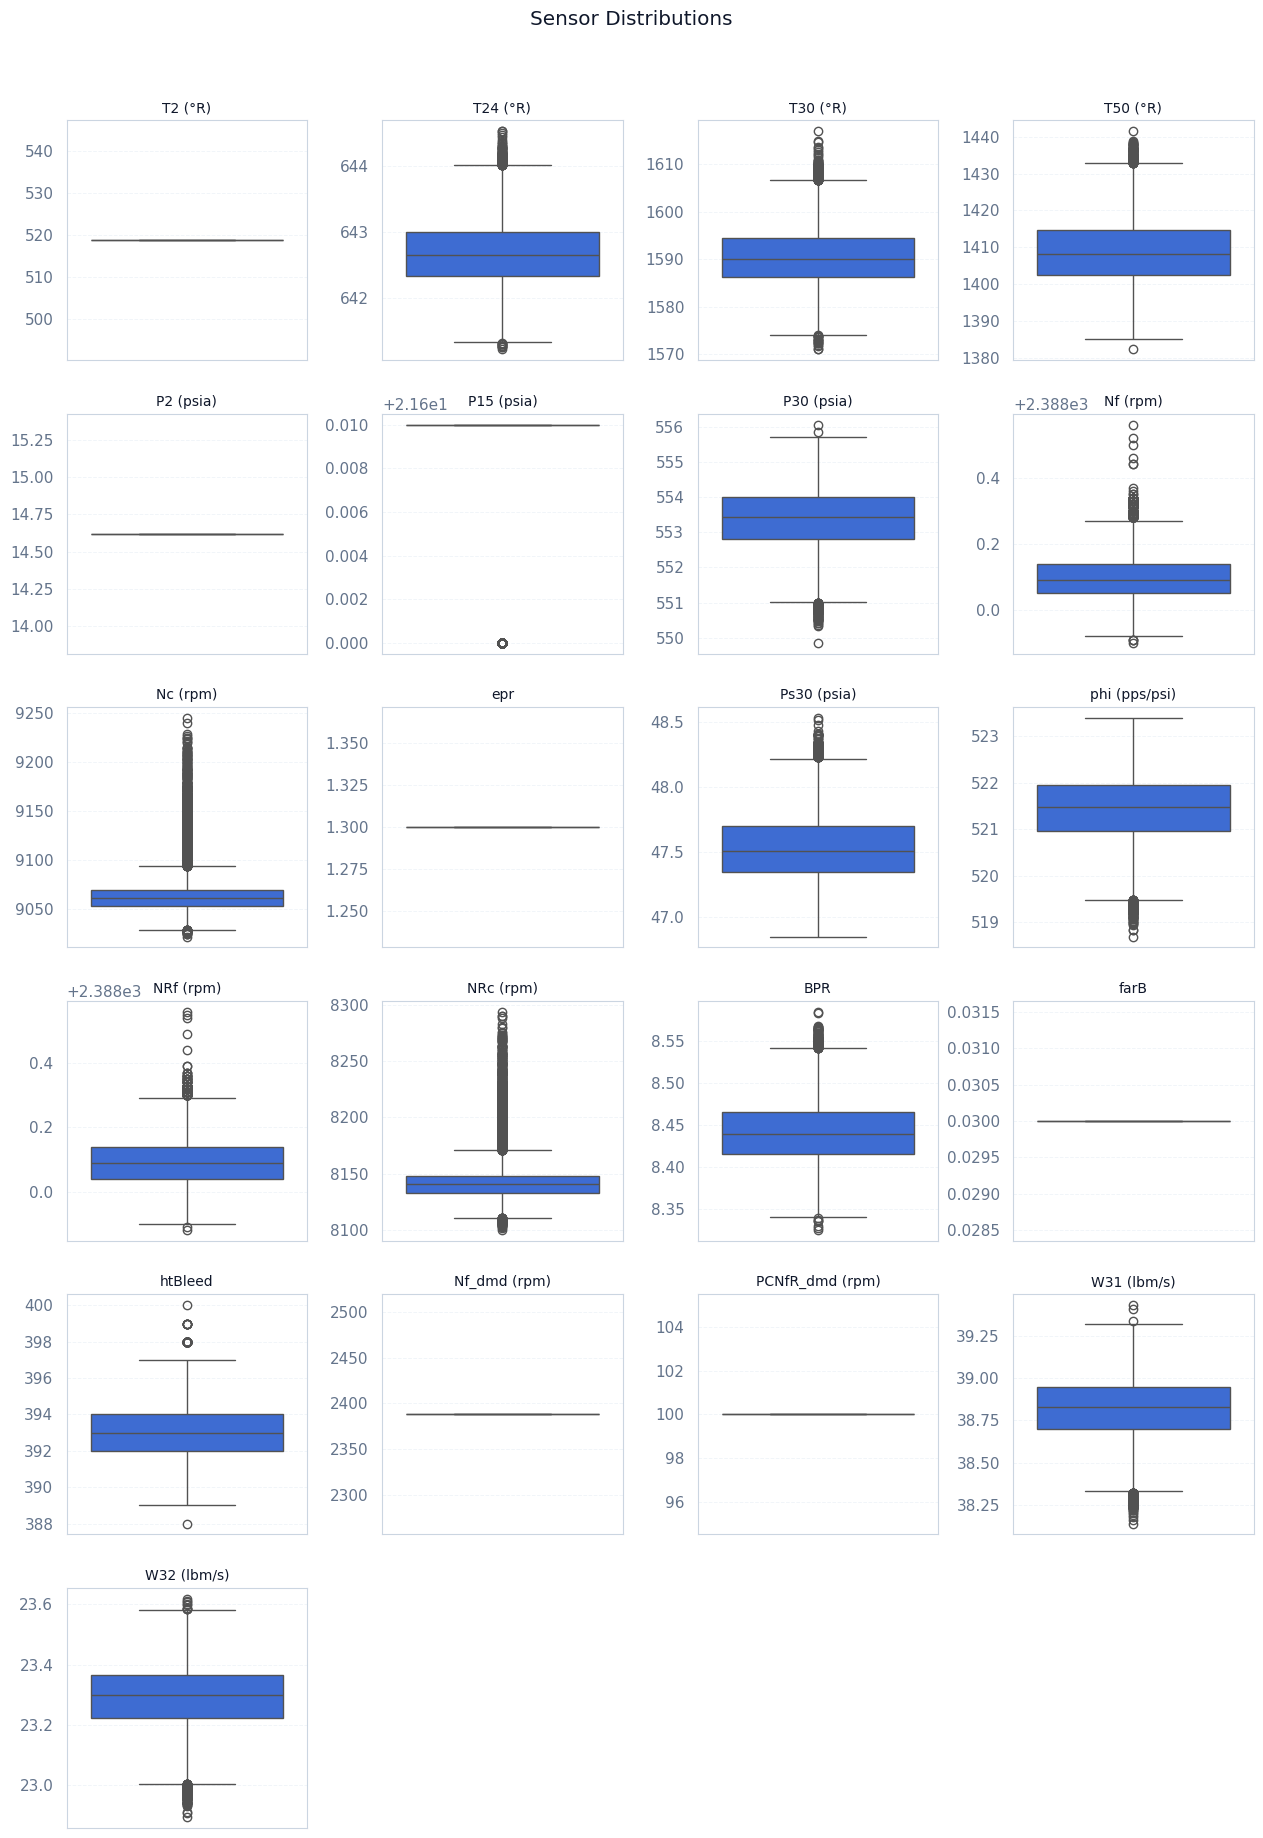


Sensor Variance Bar:


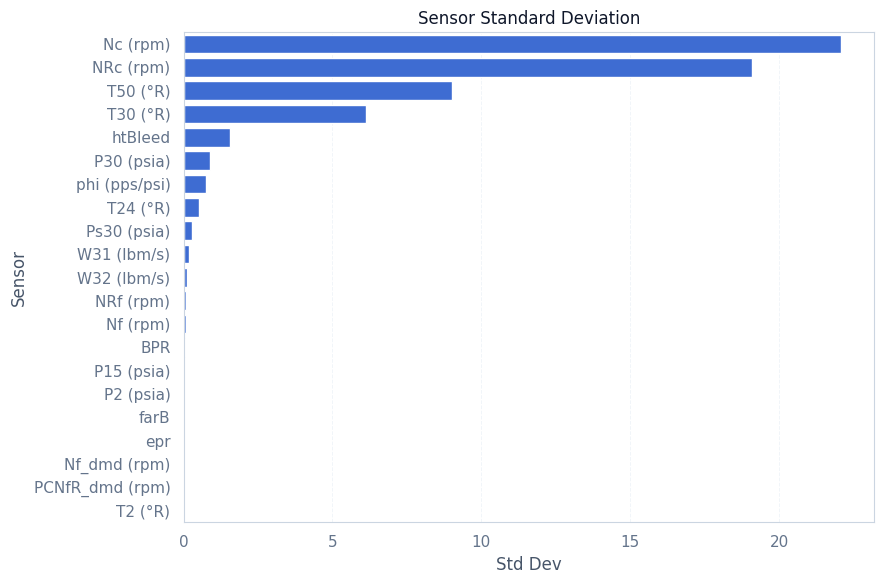

In [23]:
eda(fd001_df)

In [24]:
fd001_df['RUL'] = unit_lifetimes(fd001_df).reindex(fd001_df['unit_number']).values - fd001_df['time_cycles']

fd001_df.tail()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measure_1,sensor_measure_2,sensor_measure_3,sensor_measure_4,sensor_measure_5,...,sensor_measure_13,sensor_measure_14,sensor_measure_15,sensor_measure_16,sensor_measure_17,sensor_measure_18,sensor_measure_19,sensor_measure_20,sensor_measure_21,RUL
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735,4
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594,3
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333,2
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640,1
20630,100,200,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,2388.26,8137.33,8.5036,0.03,396,2388,100.0,38.37,23.0522,0


In [25]:
fd001_clean, fd001_dropped = drop_constant_sensors(fd001_df)
print('Dropped constant sensors: ', fd001_dropped)

Dropped constant sensors:  ['sensor_measure_1', 'sensor_measure_5', 'sensor_measure_6', 'sensor_measure_10', 'sensor_measure_16', 'sensor_measure_18', 'sensor_measure_19']


In [26]:
fd001_clean_clipped = clip_rul(fd001_clean)
fd001_clean_clipped[['unit_number', 'time_cycles', 'RUL']].head()

,unit_number,time_cycles,RUL
0,1,1,125
1,1,2,125
2,1,3,125
3,1,4,125
4,1,5,125


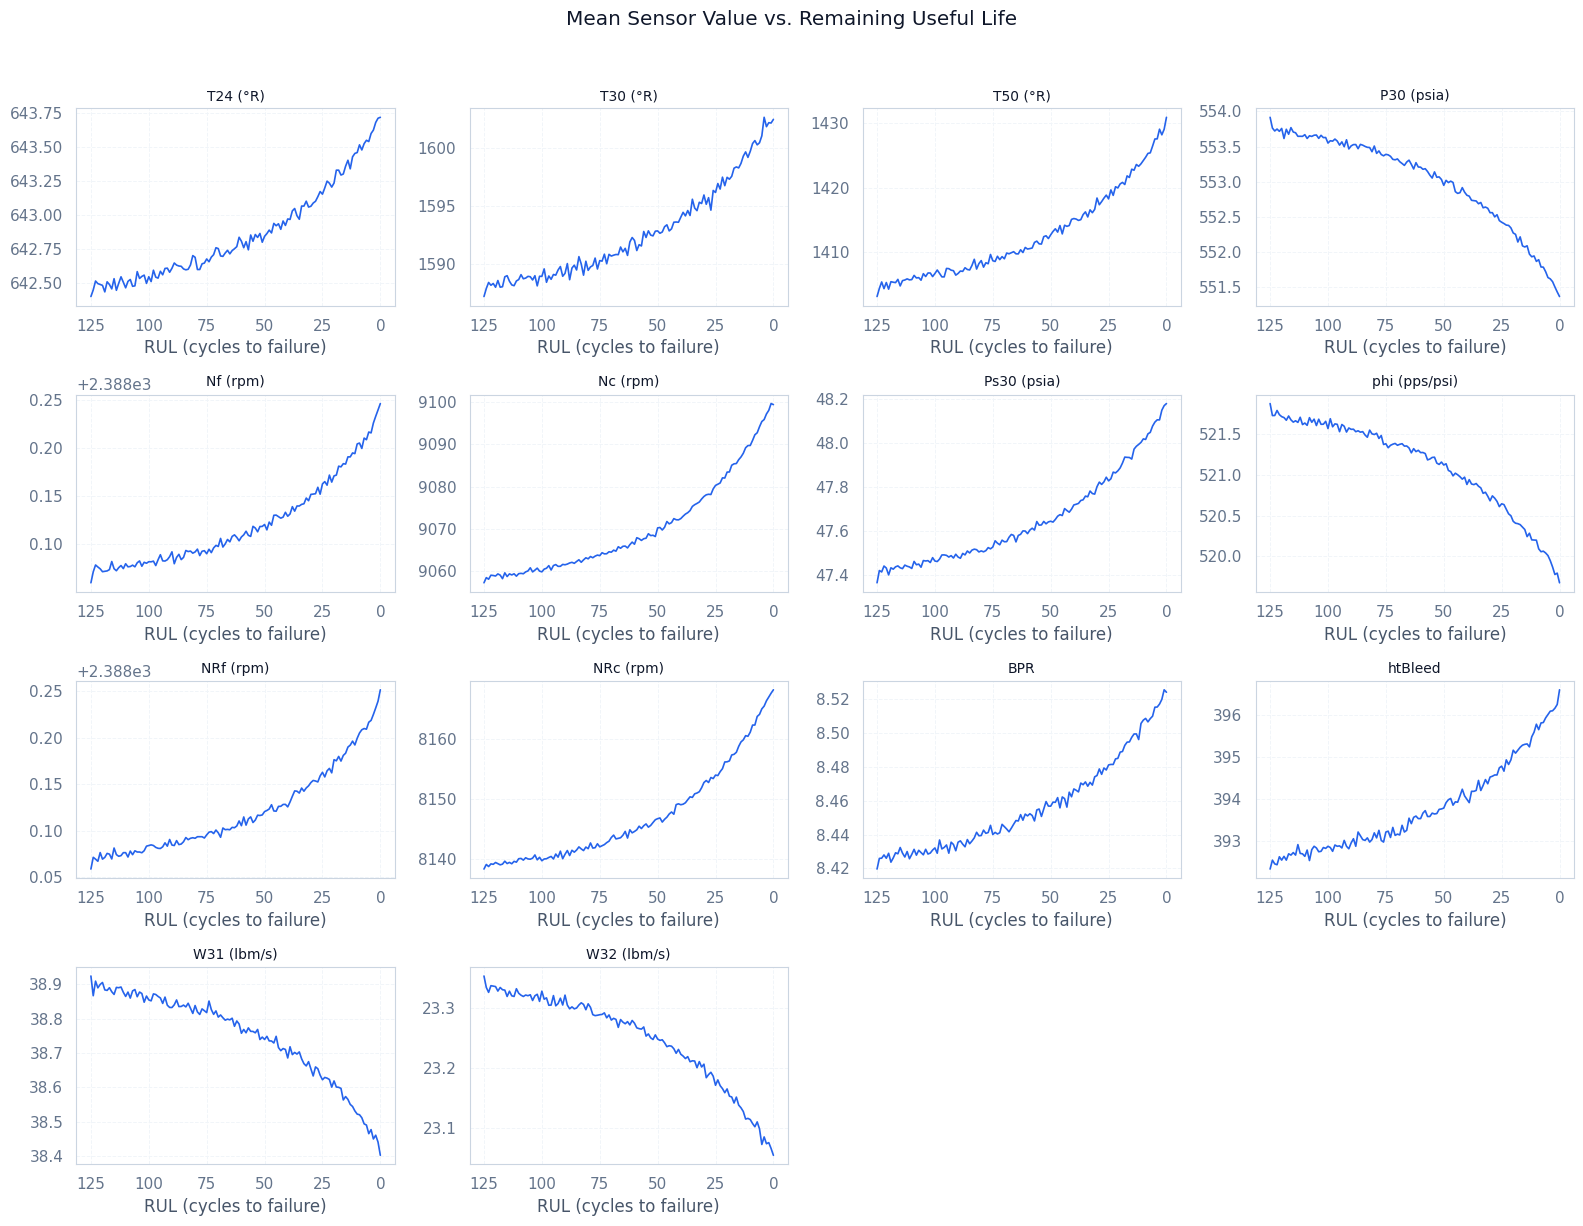

In [27]:
sensor_degradation_trend(fd001_clean_clipped, sensors=sensor_cols(fd001_clean_clipped))

## Test Data

In [28]:
fd001_test_df = load_test_data('FD001')
fd001_rul = load_rul('FD001')
fd001_test_df = attach_test_rul(fd001_test_df, fd001_rul)
fd001_test_df.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measure_1,sensor_measure_2,sensor_measure_3,sensor_measure_4,sensor_measure_5,...,sensor_measure_13,sensor_measure_14,sensor_measure_15,sensor_measure_16,sensor_measure_17,sensor_measure_18,sensor_measure_19,sensor_measure_20,sensor_measure_21,RUL
0,1,1,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,2388.03,8125.55,8.4052,0.03,392,2388,100.0,38.86,23.3735,142
1,1,2,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,2388.06,8139.62,8.3803,0.03,393,2388,100.0,39.02,23.3916,141
2,1,3,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,2388.03,8130.10,8.4441,0.03,393,2388,100.0,39.08,23.4166,140
3,1,4,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,2388.05,8132.90,8.3917,0.03,391,2388,100.0,39.00,23.3737,139
4,1,5,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,2388.03,8129.54,8.4031,0.03,390,2388,100.0,38.99,23.4130,138


## Insights

- 100 training engines and 100 test engines.
- One operating condition: sea level.
- One fault mode: HPC degradation.
- 20,631 training rows.
- Maximum lifetime: 362 cycles.
- Several sensors are constant or nearly constant and can be removed.
- Because operating conditions are stable, raw sensor trends are easier to interpret.
- FD001 is the dataset to establish the baseline.

# FD003 EDA

## Train Data

In [29]:
fd003_df = load_training_data('FD003')
fd003_df.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measure_1,sensor_measure_2,sensor_measure_3,sensor_measure_4,sensor_measure_5,...,sensor_measure_12,sensor_measure_13,sensor_measure_14,sensor_measure_15,sensor_measure_16,sensor_measure_17,sensor_measure_18,sensor_measure_19,sensor_measure_20,sensor_measure_21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


Data Summary:


,Metric,Value
0,Rows,24720
1,Units,100
2,Max Cycle,525
3,Missing values,0
4,Duplicate rows,0



Sensor Reference:


,column,symbol,description,unit
0,sensor_measure_1,T2,Total temperature at fan inlet,°R
1,sensor_measure_2,T24,Total temperature at LPC outlet,°R
2,sensor_measure_3,T30,Total temperature at HPC outlet,°R
3,sensor_measure_4,T50,Total temperature at LPT outlet,°R
4,sensor_measure_5,P2,Pressure at fan inlet,psia
5,sensor_measure_6,P15,Total pressure in bypass-duct,psia
6,sensor_measure_7,P30,Total pressure at HPC outlet,psia
7,sensor_measure_8,Nf,Physical fan speed,rpm
8,sensor_measure_9,Nc,Physical core speed,rpm
9,sensor_measure_10,epr,Engine pressure ratio (P50/P2),--



Sensor Variance Classification:


,Sensor,Variance,Classification
0,sensor_measure_1,0.000000e+00,Low
1,sensor_measure_2,2.735616e-01,Medium
2,sensor_measure_3,4.638179e+01,High
3,sensor_measure_4,9.551501e+01,High
4,sensor_measure_5,1.262229e-29,Low
5,sensor_measure_6,3.281895e-04,Low
6,sensor_measure_7,1.181533e+01,High
7,sensor_measure_8,2.505412e-02,Low
8,sensor_measure_9,3.992122e+02,High
9,sensor_measure_10,1.214417e-05,Low



RUL Distribution:


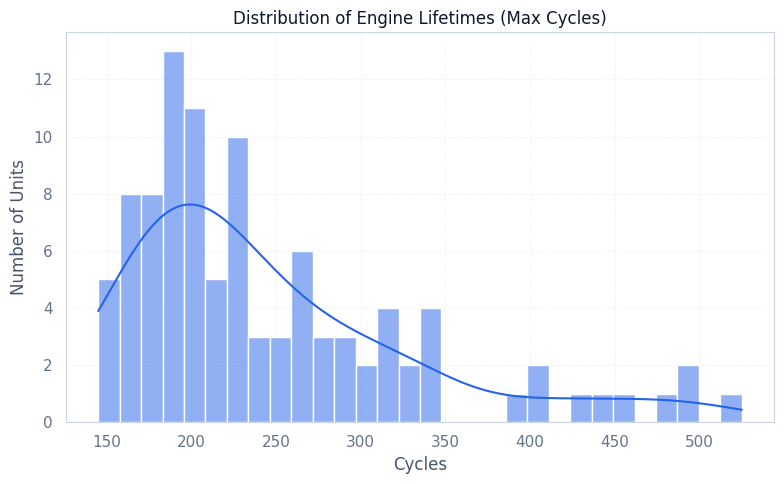


Sensor Grid:


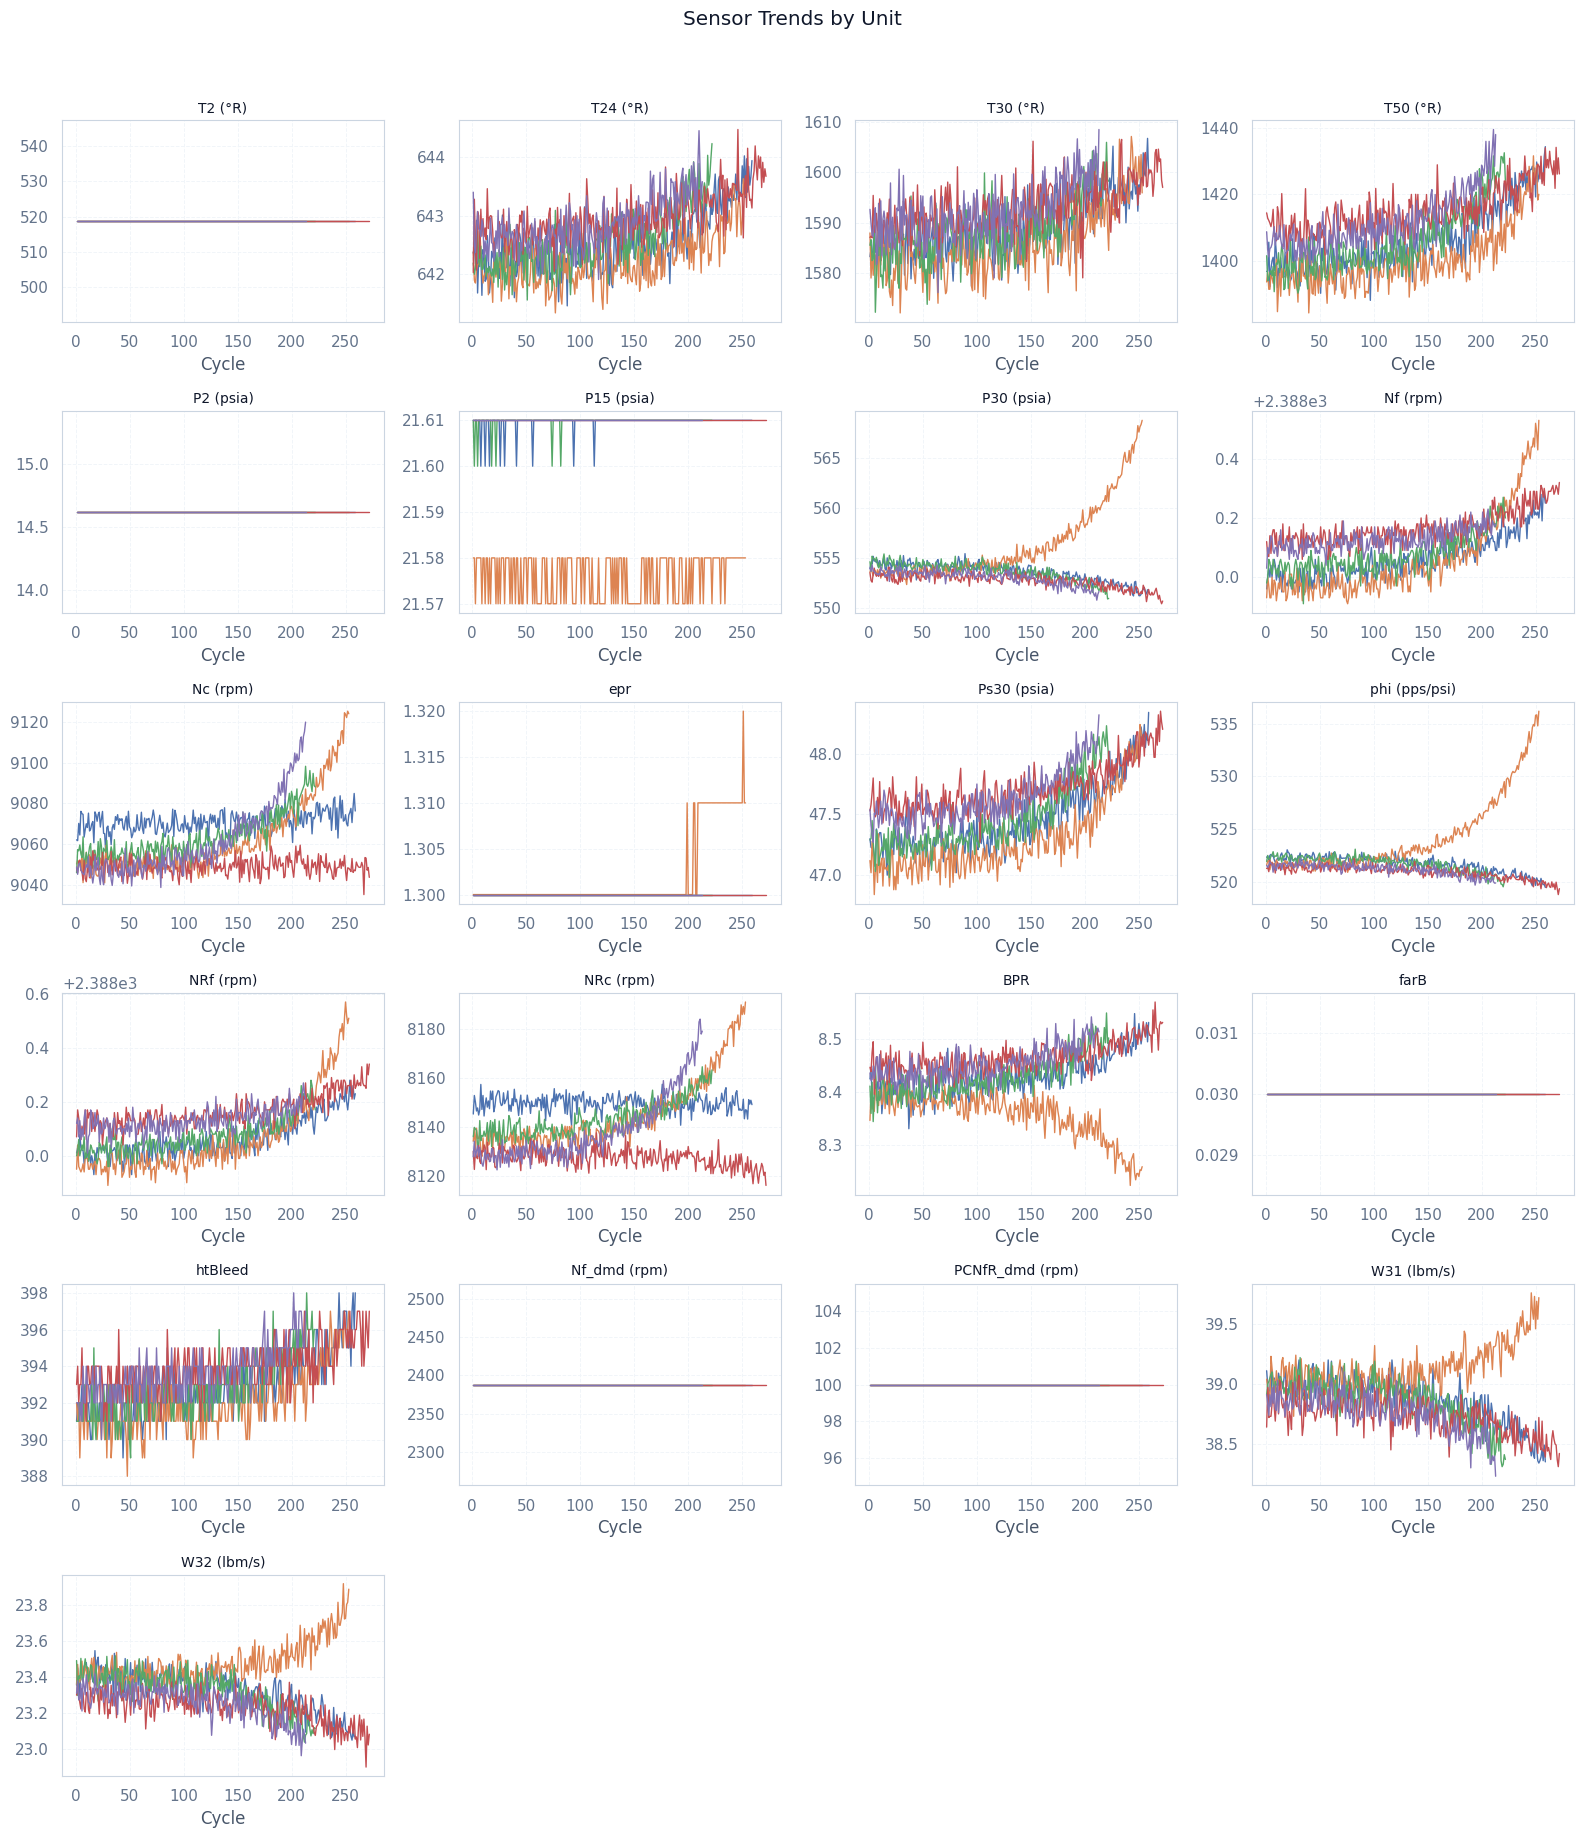


Correlation Heatmap:


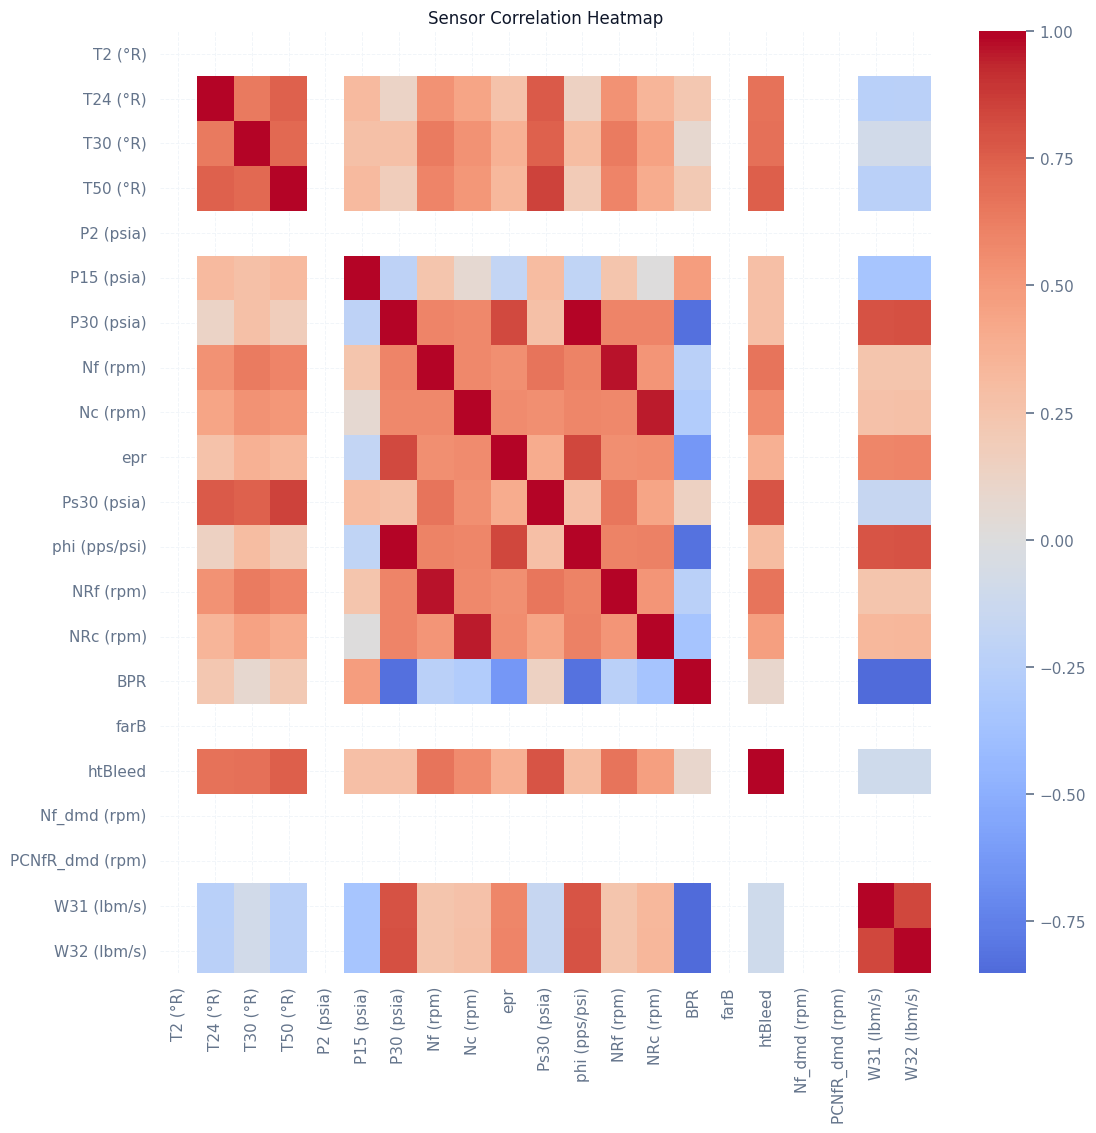


Sensor Boxplot Grid:


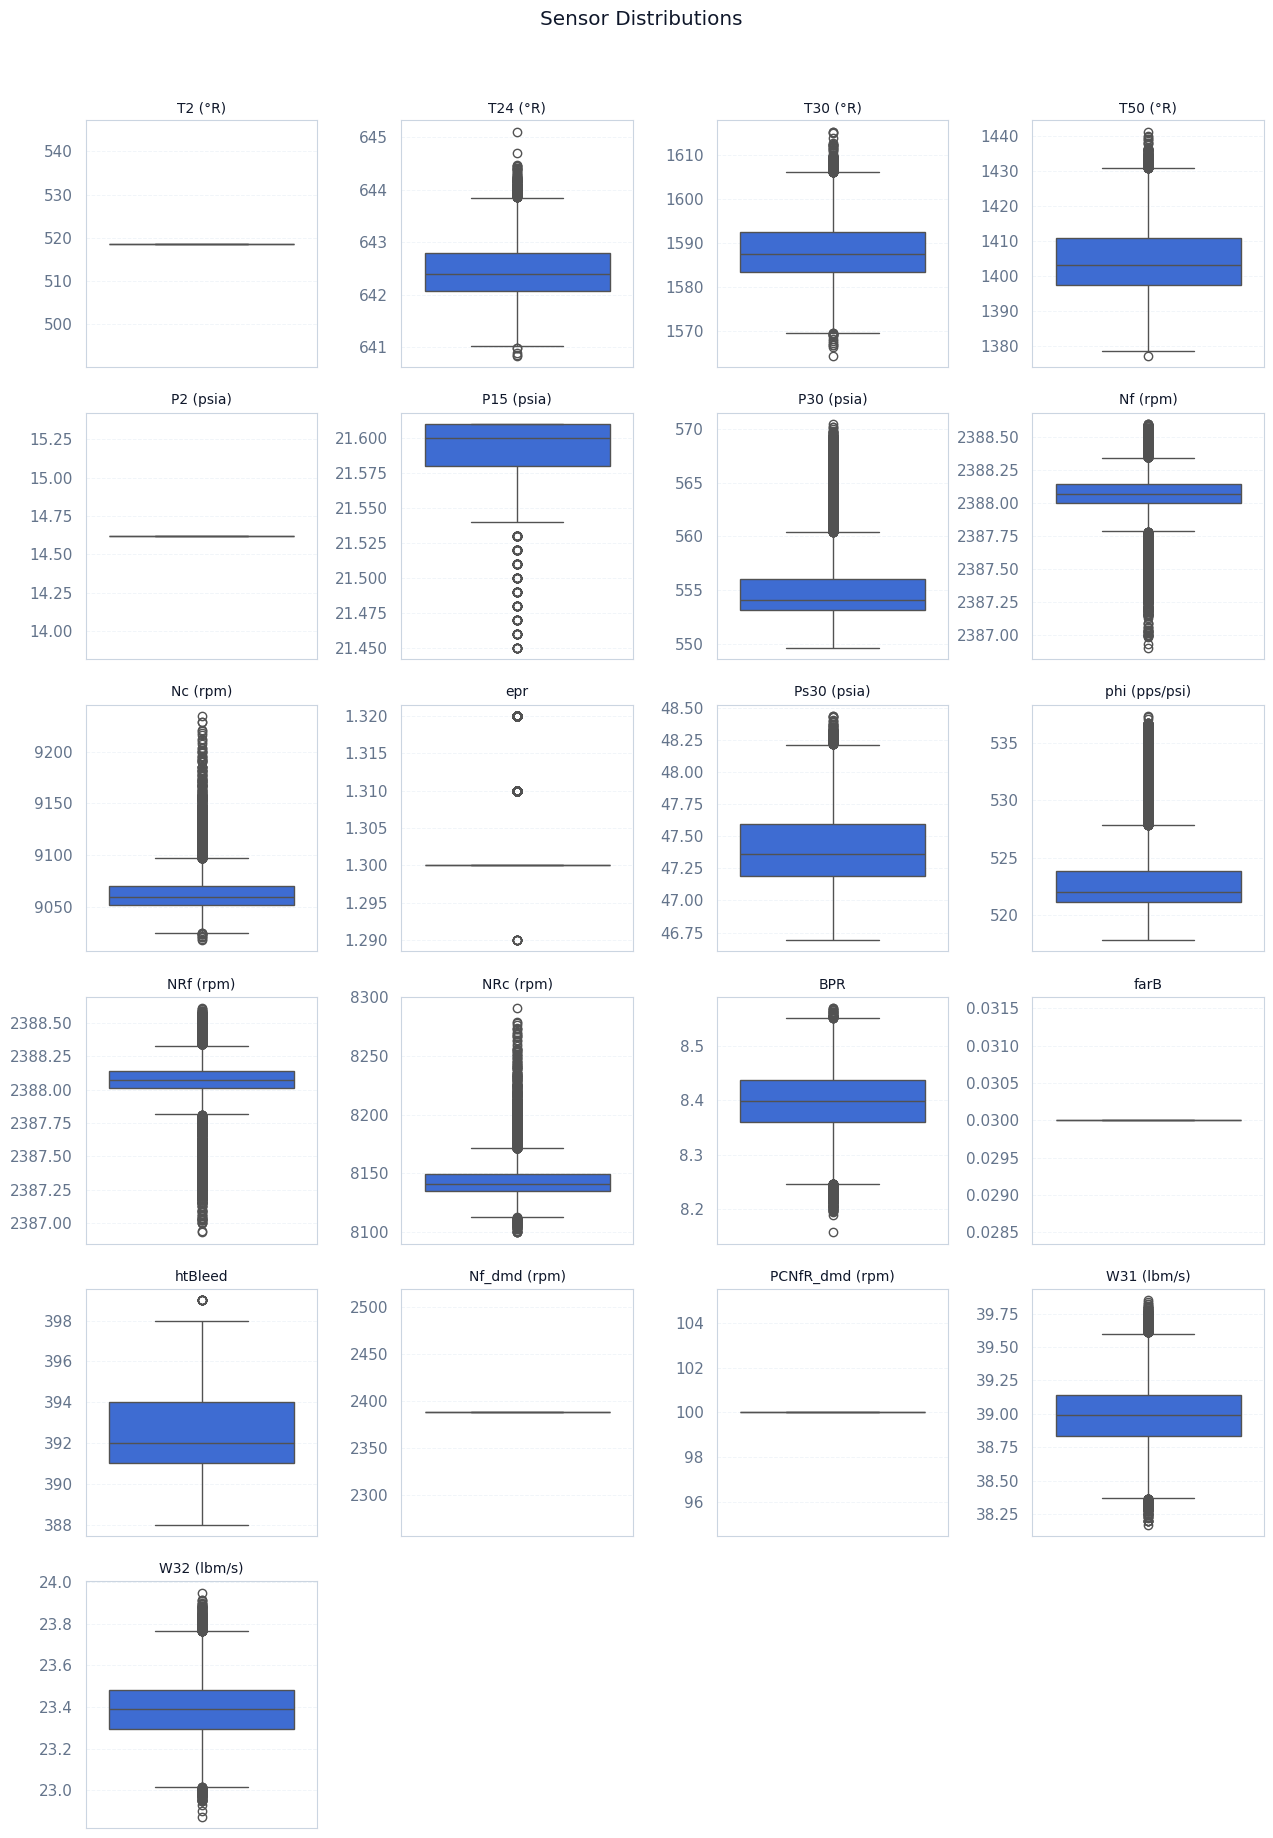


Sensor Variance Bar:


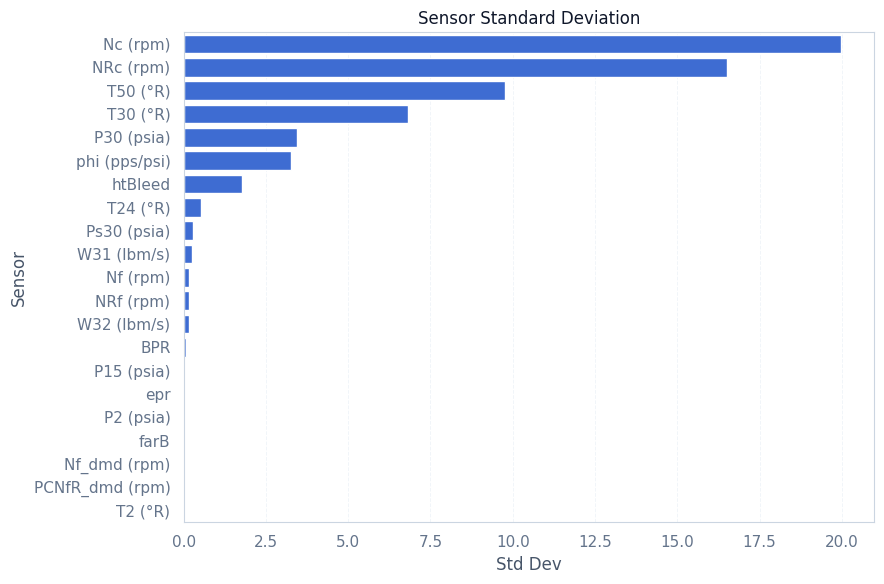

In [30]:
eda(fd003_df)

In [31]:
fd003_df['RUL'] = unit_lifetimes(fd003_df).reindex(fd003_df['unit_number']).values - fd003_df['time_cycles']

In [32]:
fd003_clean, fd003_dropped = drop_constant_sensors(fd003_df)
print('Dropped constant sensors: ', fd003_dropped)

Dropped constant sensors:  ['sensor_measure_1', 'sensor_measure_5', 'sensor_measure_16', 'sensor_measure_18', 'sensor_measure_19']


In [33]:
fd003_clean_clipped = clip_rul(fd003_clean)
fd003_clean_clipped[['unit_number', 'time_cycles', 'RUL']].tail()

,unit_number,time_cycles,RUL
24715,100,148,4
24716,100,149,3
24717,100,150,2
24718,100,151,1
24719,100,152,0


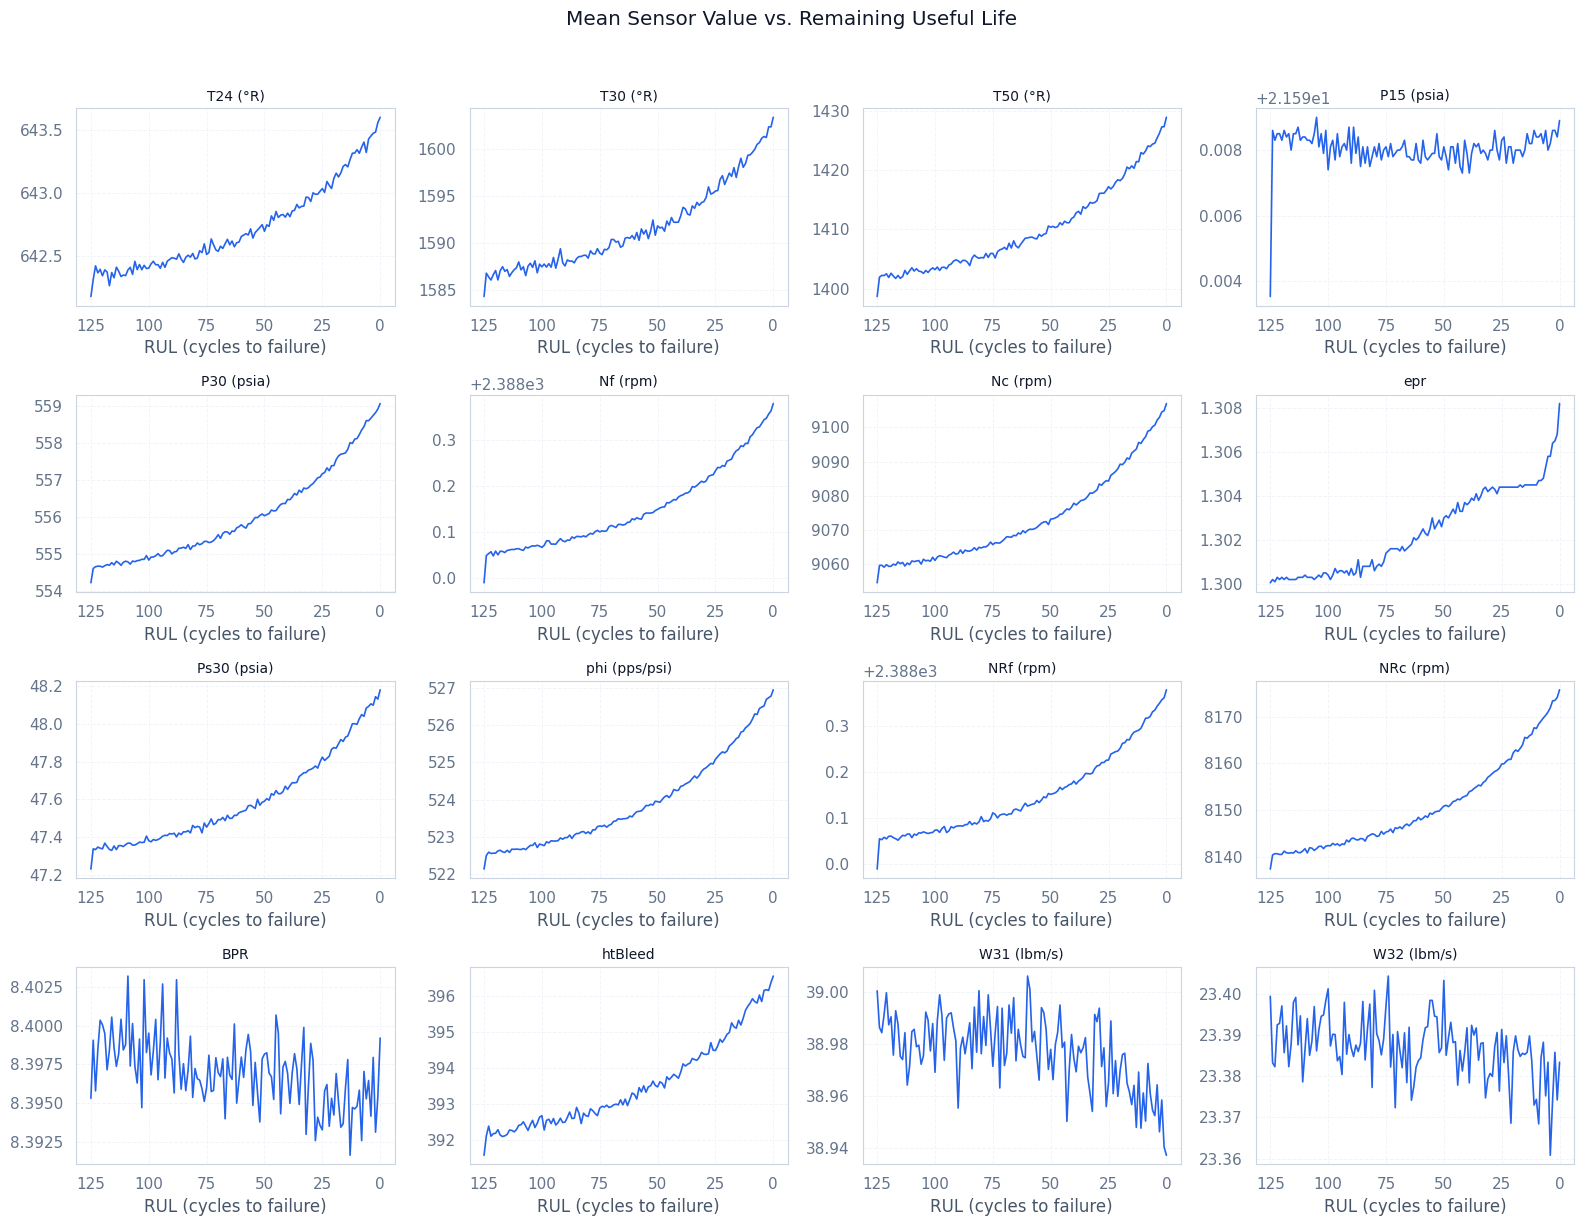

In [34]:
sensor_degradation_trend(fd003_clean_clipped, sensors=sensor_cols(fd003_clean_clipped))

## Test Data

In [35]:
fd003_test_df = load_test_data('FD003')
fd003_rul = load_rul('FD003')
fd003_test_df = attach_test_rul(fd003_test_df, fd003_rul)
fd003_test_df.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_measure_1,sensor_measure_2,sensor_measure_3,sensor_measure_4,sensor_measure_5,...,sensor_measure_13,sensor_measure_14,sensor_measure_15,sensor_measure_16,sensor_measure_17,sensor_measure_18,sensor_measure_19,sensor_measure_20,sensor_measure_21,RUL
0,1,1,-0.0017,-0.0004,100.0,518.67,641.94,1581.93,1396.93,14.62,...,2387.94,8133.48,8.3760,0.03,391,2388,100.0,39.07,23.4468,276
1,1,2,0.0006,-0.0002,100.0,518.67,642.02,1584.86,1398.90,14.62,...,2388.01,8137.44,8.4062,0.03,391,2388,100.0,39.04,23.4807,275
2,1,3,0.0014,-0.0003,100.0,518.67,641.68,1581.78,1391.92,14.62,...,2387.94,8138.25,8.3553,0.03,391,2388,100.0,39.10,23.4244,274
3,1,4,0.0027,0.0001,100.0,518.67,642.20,1584.53,1395.34,14.62,...,2387.96,8137.07,8.3709,0.03,392,2388,100.0,38.97,23.4782,273
4,1,5,-0.0001,0.0001,100.0,518.67,642.46,1589.03,1395.86,14.62,...,2387.97,8134.20,8.4146,0.03,391,2388,100.0,39.09,23.3950,272


## Insights

- 100 training engines and 100 test engines.
- One operating condition: sea level.
- Two fault modes: HPC degradation and fan degradation.
- 24,720 training rows.
- Maximum lifetime: 525 cycles.
- FD003 has longer and more varied engine trajectories than FD001.
- This dataset is a stronger test of whether the models learn general degradation rather than only one fault pattern.

## FD002 and FD004

FD002 and FD004 are six-operating-condition datasets. FD002 contains HPC and FD004 contains both HPC and fan degradation fault mode. These datasets are not included during this stage because they are more complex and require additional preprocessing. We might include it in further stages.